In [1]:
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing Face Mask Dataset

In [3]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown


In [4]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [5]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


Importing the Dependencies

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [7]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_2853.jpg', 'with_mask_3361.jpg', 'with_mask_48.jpg', 'with_mask_2896.jpg', 'with_mask_1120.jpg']
['with_mask_3144.jpg', 'with_mask_1246.jpg', 'with_mask_50.jpg', 'with_mask_2640.jpg', 'with_mask_532.jpg']


In [8]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_3344.jpg', 'without_mask_2033.jpg', 'without_mask_344.jpg', 'without_mask_3507.jpg', 'without_mask_3652.jpg']
['without_mask_519.jpg', 'without_mask_3754.jpg', 'without_mask_995.jpg', 'without_mask_3593.jpg', 'without_mask_1202.jpg']


In [9]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


Creating Labels for the two class of Images

In [10]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [11]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [12]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [13]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


Displaying the Images

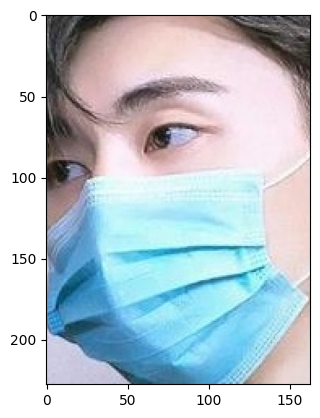

In [14]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

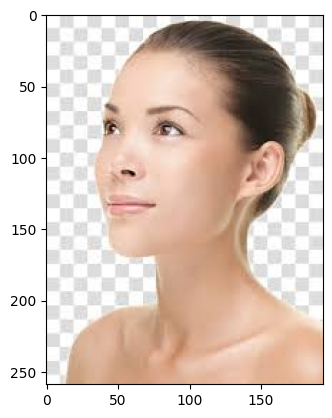

In [15]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

Image Processing

1. Resize the Images

2. Convert the images to numpy arrays

In [16]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [17]:
type(data)

list

In [18]:
len(data)

7553

array([[[213, 213, 201],
        [214, 214, 202],
        [214, 214, 202],
        ...,
        [234, 234, 224],
        [234, 234, 224],
        [234, 234, 224]],

       [[213, 213, 201],
        [213, 213, 201],
        [214, 214, 202],
        ...,
        [234, 234, 224],
        [234, 234, 224],
        [234, 234, 224]],

       [[212, 212, 200],
        [212, 212, 200],
        [212, 212, 200],
        ...,
        [234, 234, 224],
        [234, 234, 224],
        [234, 234, 224]],

       ...,

       [[210, 208, 194],
        [209, 207, 195],
        [210, 208, 202],
        ...,
        [ 96, 118, 159],
        [ 95, 117, 157],
        [ 93, 115, 154]],

       [[208, 206, 191],
        [206, 204, 192],
        [210, 207, 204],
        ...,
        [ 97, 119, 159],
        [ 96, 118, 157],
        [ 93, 115, 154]],

       [[207, 205, 190],
        [205, 203, 192],
        [208, 206, 203],
        ...,
        [ 98, 120, 159],
        [ 97, 119, 158],
        [ 94, 116, 155]]], dtype=uint8)
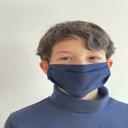

In [19]:
data[0]

In [20]:
type(data[0])

numpy.ndarray

In [21]:
data[0].shape

(128, 128, 3)

In [22]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [23]:
type(X)

numpy.ndarray

In [24]:
type(Y)

numpy.ndarray

In [25]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [26]:
print(Y)

[1 1 1 ... 0 0 0]


Train Test Split

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [28]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [29]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[204, 223, 237],
        [204, 223, 237],
        [204, 223, 237],
        ...,
        [206, 224, 238],
        [206, 224, 238],
        [206, 224, 238]],

       [[204, 223, 237],
        [204, 223, 237],
        [204, 223, 237],
        ...,
        [206, 224, 238],
        [206, 224, 238],
        [206, 224, 238]],

       [[204, 223, 237],
        [204, 223, 237],
        [204, 223, 237],
        ...,
        [206, 224, 238],
        [206, 224, 238],
        [206, 224, 238]],

       ...,

       [[158, 166, 187],
        [206, 213, 236],
        [206, 213, 233],
        ...,
        [211, 187, 166],
        [204, 176, 161],
        [203, 180, 168]],

       [[194, 205, 233],
        [175, 183, 212],
        [194, 200, 224],
        ...,
        [212, 196, 183],
        [210, 193, 182],
        [202, 189, 181]],

       [[169, 180, 228],
        [153, 162, 200],
        [214, 220, 236],
        ...,
        [210, 201, 195],
        [205, 198, 192],
        [199, 192, 186]]], dtype=uint8)
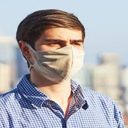

In [30]:
X_train[0]

In [31]:
X_train_scaled[0]

array([[[0.8       , 0.8745098 , 0.92941176],
        [0.8       , 0.8745098 , 0.92941176],
        [0.8       , 0.8745098 , 0.92941176],
        ...,
        [0.80784314, 0.87843137, 0.93333333],
        [0.80784314, 0.87843137, 0.93333333],
        [0.80784314, 0.87843137, 0.93333333]],

       [[0.8       , 0.8745098 , 0.92941176],
        [0.8       , 0.8745098 , 0.92941176],
        [0.8       , 0.8745098 , 0.92941176],
        ...,
        [0.80784314, 0.87843137, 0.93333333],
        [0.80784314, 0.87843137, 0.93333333],
        [0.80784314, 0.87843137, 0.93333333]],

       [[0.8       , 0.8745098 , 0.92941176],
        [0.8       , 0.8745098 , 0.92941176],
        [0.8       , 0.8745098 , 0.92941176],
        ...,
        [0.80784314, 0.87843137, 0.93333333],
        [0.80784314, 0.87843137, 0.93333333],
        [0.80784314, 0.87843137, 0.93333333]],

       ...,

       [[0.61960784, 0.65098039, 0.73333333],
        [0.80784314, 0.83529412, 0.9254902 ],
        [0.80784314, 0

Building a Convolutional Neural Networks (CNN)

In [32]:
import tensorflow as tf
from tensorflow import keras

In [33]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [35]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - acc: 0.6509 - loss: 0.7254 - val_acc: 0.8893 - val_loss: 0.2767
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - acc: 0.8910 - loss: 0.2818 - val_acc: 0.8992 - val_loss: 0.2157
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.9136 - loss: 0.2267 - val_acc: 0.9025 - val_loss: 0.2264
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.9270 - loss: 0.1815 - val_acc: 0.9025 - val_loss: 0.2178
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.9411 - loss: 0.1523 - val_acc: 0.9074 - val_loss: 0.2198


Model Evaluation

In [36]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9338 - loss: 0.1891
Test Accuracy = 0.9258769154548645


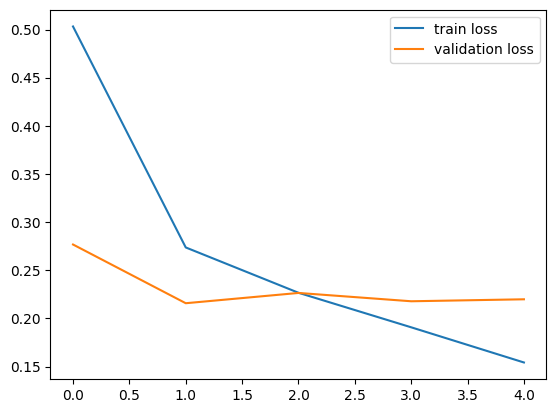

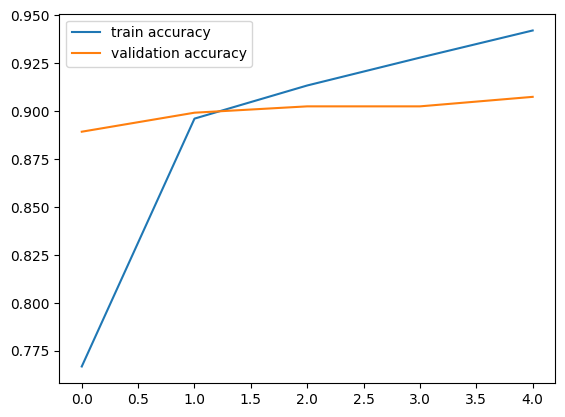

In [37]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

Predictive System

Path of the image to be predicted: /content/data/with_mask/with_mask_1001.jpg


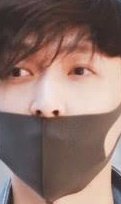

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step
[[0.4804437  0.48370057]]
1
The person in the image is wearing a mask


In [38]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')